# 05 - EDA inicial pre fuentes externas

**Objetivo.** Analizar la base inmobiliaria limpia antes de sumar fuentes externas, geocodificación, dólar diario o variables territoriales avanzadas. Este notebook funciona como una foto inicial del mercado con los datos propios ya normalizados.

**Qué se busca en esta etapa**

- Entender composición de la base por fuente, operación y moneda.
- Revisar cobertura remanente de variables críticas.
- Explorar distribuciones de precio, superficie, precio/m², ambientes y expensas.
- Detectar límites de comparabilidad antes del enriquecimiento externo.
- Dejar interpretaciones preliminares y preguntas abiertas para notebooks 06 y 07.

**Qué no se hace acá.** No se calculan distancias, no se usa Censo, no se corrigen barrios con fuentes oficiales y no se contrastan hipótesis de forma definitiva.

## 1. Preparación del entorno

In [7]:
from pathlib import Path
import json
import re
import unicodedata
from datetime import datetime

import numpy as np
import pandas as pd


try:
    from IPython.display import display
except Exception:
    display = print

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    import matplotlib.pyplot as plt
    HAS_SEABORN = False

pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 180)


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw').exists() and (path / 'README.md').exists():
            return path
    raise FileNotFoundError('No se encontro la raiz del repo. Ejecutar dentro del proyecto.')


REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / 'data' / 'raw'
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
REPORTS_DIR = PROCESSED_DIR / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT:', REPO_ROOT)
print('PROCESSED_DIR:', PROCESSED_DIR)
print('REPORTS_DIR:', REPORTS_DIR)


Cloning into 'TP_analitica_descriptiva_grupo1_2q2026'...
remote: Enumerating objects: 949, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 949 (delta 21), reused 37 (delta 16), pack-reused 900 (from 2)
Receiving objects: 100% (949/949), 238.90 MiB | 16.87 MiB/s, done.
Resolving deltas: 100% (520/520), done.
Updating files: 100% (244/244), done.
Directorio actual: /content/TP_analitica_descriptiva_grupo1_2q2026/TP_analitica_descriptiva_grupo1_2q2026
REPO_ROOT: /content/TP_analitica_descriptiva_grupo1_2q2026/TP_analitica_descriptiva_grupo1_2q2026
PROCESSED_DIR: /content/TP_analitica_descriptiva_grupo1_2q2026/TP_analitica_descriptiva_grupo1_2q2026/data/processed
REPORTS_DIR: /content/TP_analitica_descriptiva_grupo1_2q2026/TP_analitica_descriptiva_grupo1_2q2026/data/processed/reports


## 2. Carga de la base inmobiliaria limpia

Se carga la base consolidada más avanzada disponible antes de fuentes externas. Si no existiera una consolidada, el notebook reconstruye una base mínima desde los archivos individuales procesados.

In [8]:
BASE_CONSOLIDADA_CANDIDATES = [
    PROCESSED_DIR / 'df_publicaciones_consolidadas_con_outliers_v1.csv',
    PROCESSED_DIR / 'df_publicaciones_consolidadas_con_flags_nulos_v1.csv',
    PROCESSED_DIR / 'df_publicaciones_consolidadas_v1.csv',
]

DATASETS_PIPELINE = [
    'df_preprocesado_meli_alq',
    'df_preprocesado_meli_alq_temp',
    'df_preprocesado_meli_vtas',
    'df_preprocesado_airbnb_temp',
    'df_preprocesado_argenprop_vtas',
    'df_preprocesado_argenprop_alq',
    'df_preprocesado_zonaprop_vtas',
    'df_preprocesado_zonaprop_alq',
]

CANONICAL_COLS = [
    'id_publicacion', 'fuente_norm', 'fuente', 'tipo_operacion_norm', 'tipo_operacion', 'url',
    'fecha_extraccion', 'scraped_at_utc', '_archivo_origen', 'dataset_preprocesado',
    'titulo', 'descripcion', 'tipo_propiedad', 'moneda_norm', 'moneda', 'precio', 'precio_texto',
    'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado', 'barrio', 'barrio_norm',
    'comuna', 'provincia', 'pais', 'direccion', 'direccion_completa', 'calle', 'altura',
    'latitud', 'longitud', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref',
    'cocheras', 'expensas', 'expensas_moneda', 'balcon', 'terraza', 'pileta', 'parrilla',
    'cochera_mencionada', 'amenities_mencionadas'
]


def construir_base_consolidada_desde_individuales(processed_dir):
    frames = []
    fuentes_usadas = []

    for name in DATASETS_PIPELINE:
        candidates = [
            processed_dir / f'{name}_con_outliers_v1.csv',
            processed_dir / f'{name}_post_ajustes_con_flags_nulos_v1.csv',
            processed_dir / f'{name}_con_flags_nulos_v1.csv',
            processed_dir / f'{name}_v1.csv',
        ]
        source = next((path for path in candidates if path.exists()), None)
        if source is None:
            continue

        df = pd.read_csv(source, low_memory=False)
        cols = [
            col for col in df.columns
            if col in CANONICAL_COLS or col.endswith('_is_null') or 'outlier' in col.lower()
        ]
        tmp = df[cols].copy()
        tmp['dataset_preprocesado'] = name
        tmp['_archivo_base_usado'] = source.name
        frames.append(tmp)
        fuentes_usadas.append({'dataset': name, 'archivo': source.name, 'filas': len(tmp)})

    if not frames:
        raise FileNotFoundError('No existe base consolidada ni archivos individuales procesados. Ejecutar notebooks 02-04.')

    return pd.concat(frames, ignore_index=True, sort=False), pd.DataFrame(fuentes_usadas)


base_path = next((path for path in BASE_CONSOLIDADA_CANDIDATES if path.exists()), None)

if base_path is not None:
    df_eda = pd.read_csv(base_path, low_memory=False)
    fuentes_usadas = pd.DataFrame([{'archivo': base_path.name, 'filas': len(df_eda), 'tipo': 'base_consolidada'}])
    print('Base usada:', base_path.relative_to(REPO_ROOT), df_eda.shape)
else:
    df_eda, fuentes_usadas = construir_base_consolidada_desde_individuales(PROCESSED_DIR)
    print('Base construida desde archivos individuales procesados:', df_eda.shape)

display(fuentes_usadas)

# Asegurar columnas de agrupación esperadas.
for col in ['fuente_norm', 'tipo_operacion_norm', 'moneda_norm', 'barrio_norm']:
    if col not in df_eda.columns:
        df_eda[col] = pd.NA

# Versiones auxiliares para graficar sin romper por nulos.
df_eda['fuente_plot'] = df_eda['fuente_norm'].fillna('sin_fuente')
df_eda['operacion_plot'] = df_eda['tipo_operacion_norm'].fillna('sin_operacion')
df_eda['moneda_plot'] = df_eda['moneda_norm'].fillna('sin_moneda')

Base usada: data/processed/df_publicaciones_consolidadas_con_outliers_v1.csv (67887, 109)


,archivo,filas,tipo
0,df_publicaciones_consolidadas_con_outliers_v1.csv,67887,base_consolidada


## 3. Dimensión y composición general

Primero se mira el tamaño efectivo de la base y la mezcla de fuentes/operaciones. Esto permite saber qué segmentos tienen volumen suficiente y cuáles conviene tratar con cautela.

,metrica,valor
0,filas,67887
1,columnas,112
2,fuentes,4
3,operaciones,3
4,barrios_norm_distintos,223
5,comunas_distintas,15


operacion_plot,alquiler,alquiler_temporal,venta,All
fuente_plot,,,,
airbnb,0,9596,0,9596
argenprop,80,0,82,162
mercado_libre,9877,4494,42778,57149
zonaprop,495,0,485,980
All,10452,14090,43345,67887


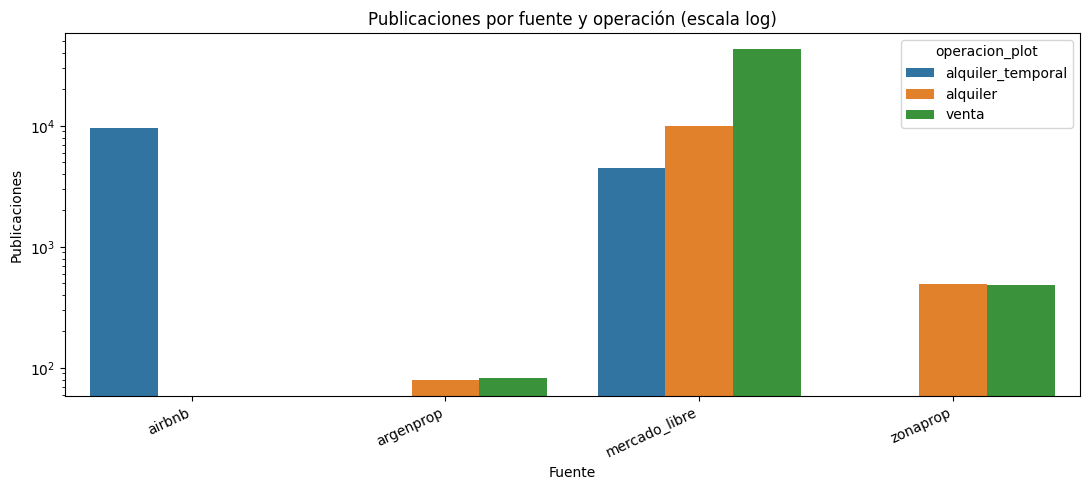

In [9]:
resumen_base = pd.DataFrame([
    {'metrica': 'filas', 'valor': len(df_eda)},
    {'metrica': 'columnas', 'valor': df_eda.shape[1]},
    {'metrica': 'fuentes', 'valor': df_eda['fuente_plot'].nunique(dropna=False)},
    {'metrica': 'operaciones', 'valor': df_eda['operacion_plot'].nunique(dropna=False)},
    {'metrica': 'barrios_norm_distintos', 'valor': df_eda['barrio_norm'].nunique(dropna=True)},
    {'metrica': 'comunas_distintas', 'valor': df_eda['comuna'].nunique(dropna=True) if 'comuna' in df_eda.columns else np.nan},
])

display(resumen_base)
resumen_base.to_csv(REPORTS_DIR / 'eda_inicial_resumen_base_v1.csv', index=False)

composicion = pd.crosstab(
    df_eda['fuente_plot'],
    df_eda['operacion_plot'],
    margins=True,
    dropna=False,
)
display(composicion)
composicion.to_csv(REPORTS_DIR / 'eda_inicial_composicion_fuente_operacion_v1.csv')

if HAS_SEABORN:
    plot_data = (
        df_eda.groupby(['fuente_plot', 'operacion_plot'])
        .size()
        .reset_index(name='publicaciones')
    )
    plt.figure(figsize=(11, 5))
    sns.barplot(data=plot_data, x='fuente_plot', y='publicaciones', hue='operacion_plot')
    plt.yscale('log')
    plt.title('Publicaciones por fuente y operación (escala log)')
    plt.xlabel('Fuente')
    plt.ylabel('Publicaciones')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

Airbnb consiste exlcusivamente de alquiler temporar; MELI concentra la mayoria de las publicaciones con distribucion relativamente uniforme.

## 4. Cobertura remanente de variables críticas

Este bloque mide cuánto dato útil queda después de limpieza/nulos/outliers. La lectura importante no es solo el porcentaje total, sino si la falta de datos se concentra en una fuente u operación.

,columna,pct_nulos,n_no_nulos,n_unicos
9,latitud,85.86,9596,3932
10,longitud,85.86,9596,4647
5,dormitorios_ref,84.25,10693,20
2,precio_m2_ref,14.33,58162,18773
3,superficie_ref_m2,14.31,58170,448
8,comuna,3.38,65594,15
6,banios_ref,2.02,66517,25
4,ambientes_ref,1.36,66962,29
7,barrio_norm,0.41,67610,223
1,moneda_norm,0.01,67879,2


,fuente_plot,operacion_plot,precio,moneda_norm,precio_m2_ref,superficie_ref_m2,ambientes_ref,dormitorios_ref,banios_ref,barrio_norm,comuna,latitud,longitud
0,airbnb,alquiler_temporal,0.0,0.0,100.0,100.0,0.0,0.0,0.1,0.8,0.8,0.0,0.0
1,argenprop,alquiler,0.0,0.0,11.2,11.2,16.2,17.5,52.5,0.0,100.0,100.0,100.0
2,argenprop,venta,0.0,0.0,4.9,4.9,8.5,18.3,58.5,0.0,100.0,100.0,100.0
3,mercado_libre,alquiler,0.0,0.0,0.4,0.4,2.8,99.6,1.9,0.2,1.7,100.0,100.0
4,mercado_libre,alquiler_temporal,0.0,0.0,0.4,0.4,3.7,99.8,2.0,0.6,3.9,100.0,100.0
5,mercado_libre,venta,0.0,0.0,0.1,0.1,1.1,99.6,2.2,0.4,1.7,100.0,100.0
6,zonaprop,alquiler,0.0,0.0,0.8,0.8,0.4,21.8,1.2,0.0,100.0,100.0,100.0
7,zonaprop,venta,1.6,1.6,1.9,0.2,0.2,21.9,10.1,0.0,100.0,100.0,100.0


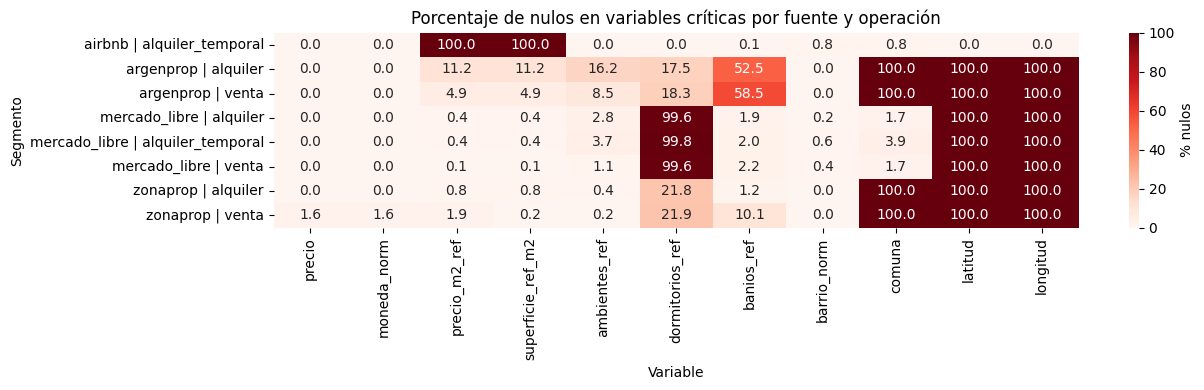

In [10]:
campos_criticos = [
    'precio', 'moneda_norm', 'precio_m2_ref', 'superficie_ref_m2', 'ambientes_ref',
    'dormitorios_ref', 'banios_ref', 'cocheras', 'expensas', 'barrio_norm', 'comuna',
    'latitud', 'longitud'
]
campos_criticos = [col for col in campos_criticos if col in df_eda.columns]

cobertura_global = pd.DataFrame({
    'columna': campos_criticos,
    'pct_nulos': [round(df_eda[col].isna().mean() * 100, 2) for col in campos_criticos],
    'n_no_nulos': [int(df_eda[col].notna().sum()) for col in campos_criticos],
    'n_unicos': [int(df_eda[col].nunique(dropna=True)) for col in campos_criticos],
}).sort_values('pct_nulos', ascending=False)

display(cobertura_global)
cobertura_global.to_csv(REPORTS_DIR / 'eda_inicial_cobertura_global_v1.csv', index=False)

cobertura_segmento = (
    df_eda.groupby(['fuente_plot', 'operacion_plot'])[campos_criticos]
    .apply(lambda x: x.isna().mean().mul(100).round(1))
    .reset_index()
)
display(cobertura_segmento)
cobertura_segmento.to_csv(REPORTS_DIR / 'eda_inicial_cobertura_por_segmento_v1.csv', index=False)

if HAS_SEABORN and campos_criticos:
    heat = cobertura_segmento.copy()
    heat['segmento'] = heat['fuente_plot'] + ' | ' + heat['operacion_plot']
    heat = heat.set_index('segmento')[campos_criticos]
    plt.figure(figsize=(13, max(4, 0.45 * len(heat))))
    sns.heatmap(heat, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': '% nulos'})
    plt.title('Porcentaje de nulos en variables críticas por fuente y operación')
    plt.xlabel('Variable')
    plt.ylabel('Segmento')
    plt.tight_layout()
    plt.show()

Las columnas criticas estan en su mayoria completas, salvo:
- Airbnb no aporta datos de superficie, problema estructural
- Dormitorios ref es faltantes estructural en MELI porque solo considera ambientes, puede reconstruirse pero la importante que es ambientes sí esta.
- La info geografica se trabajara en la entrega 3

## 5. Diagnóstico territorial inicial

Antes de corregir barrios con fuentes oficiales, se revisa cómo viene la dimensión territorial original. Este bloque justifica por qué el notebook 06 trabaja con `barrio_oficial`, GeoJSON de barrios y geocodificación.

,publicaciones
barrio_norm,
palermo,8181
recoleta,4988
belgrano,3732
caballito,3099
almagro,3068
nunez,2861
balvanera,2813
villa urquiza,2608
villa crespo,2483


Cantidad de etiquetas de barrio con 3 publicaciones o menos: 139


,publicaciones
barrio_norm,
blanco encalada,3
fray justo santa maria de oro,3
avenida olazabal,3
nueva_pompeya,3
abasto,3
centro / microcentro,3
billinghurst,3
jeronimo salguero,3
sanchez de bustamante,3


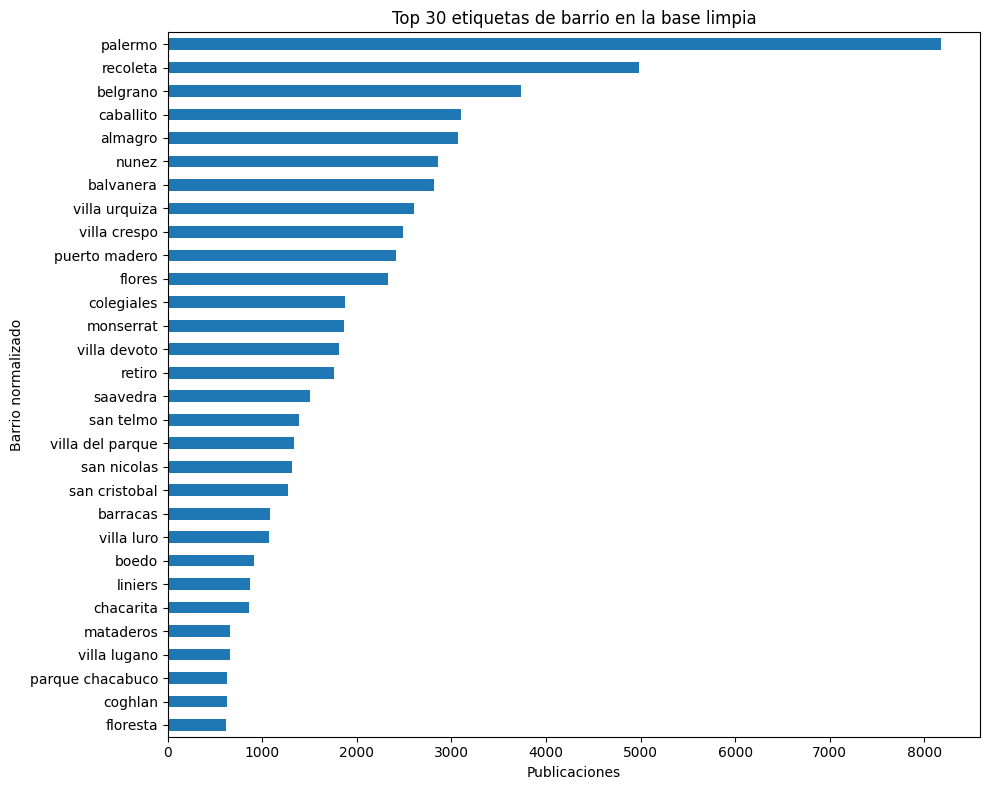

,publicaciones
comuna,
1.0,10130
10.0,1898
11.0,3257
12.0,5320
13.0,8459
14.0,8030
15.0,4614
2.0,4748
3.0,4110


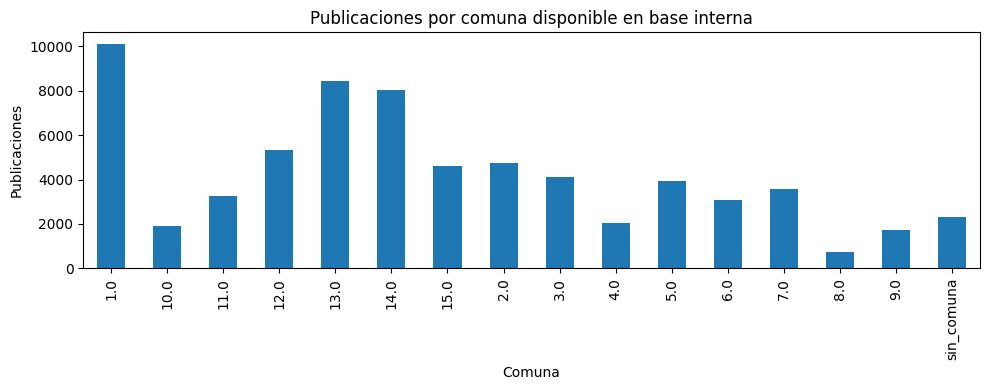

In [11]:
if 'barrio_norm' in df_eda.columns:
    barrios_top = df_eda['barrio_norm'].fillna('sin_barrio').value_counts().head(30)
    barrios_baja_frecuencia = df_eda['barrio_norm'].value_counts(dropna=True).loc[lambda s: s <= 3].head(30)

    display(barrios_top.to_frame('publicaciones'))
    print('Cantidad de etiquetas de barrio con 3 publicaciones o menos:', int((df_eda['barrio_norm'].value_counts(dropna=True) <= 3).sum()))
    display(barrios_baja_frecuencia.to_frame('publicaciones'))

    plt.figure(figsize=(10, 8))
    barrios_top.sort_values().plot(kind='barh')
    plt.title('Top 30 etiquetas de barrio en la base limpia')
    plt.xlabel('Publicaciones')
    plt.ylabel('Barrio normalizado')
    plt.tight_layout()
    plt.show()

if 'comuna' in df_eda.columns:
    comuna_plot = df_eda['comuna'].astype('string').fillna('sin_comuna')
    comuna_counts = comuna_plot.value_counts().sort_index(key=lambda idx: idx.astype(str))
    display(comuna_counts.to_frame('publicaciones'))

    plt.figure(figsize=(10, 4))
    comuna_counts.plot(kind='bar')
    plt.title('Publicaciones por comuna disponible en base interna')
    plt.xlabel('Comuna')
    plt.ylabel('Publicaciones')
    plt.tight_layout()
    plt.show()

Existen una gran cantidad de barrios incorrectos. Estos se transformaran utilziando ubicacion geografica mas adelante. Los barrios con mas publicaciones suelen ser los mas poblados y frecuentados, lo que se complementara con data del censo.

## 6. Distribución de precios por operación y moneda

Se recorta por percentiles 1 y 99 dentro de cada operación-moneda para visualizar sin que pocos extremos dominen el gráfico. El tratamiento de outliers ya fue documentado antes; acá se busca lectura exploratoria.

,operacion_plot,moneda_plot,n,mediana,media,p25,p75
0,alquiler,ARS,7312,750000.0,8.611633e+05,650000.00,9.800000e+05
1,alquiler,USD,2956,1300.0,1.964030e+03,850.00,2.400000e+03
2,alquiler_temporal,ARS,1462,700000.0,7.257591e+05,580000.00,8.900000e+05
3,alquiler_temporal,USD,12347,75.1,5.140000e+02,50.03,3.206800e+02
4,venta,ARS,3,124726000.0,1.004047e+08,63113000.00,1.498570e+08
5,venta,USD,42483,138000.0,1.945022e+05,92433.50,2.200000e+05


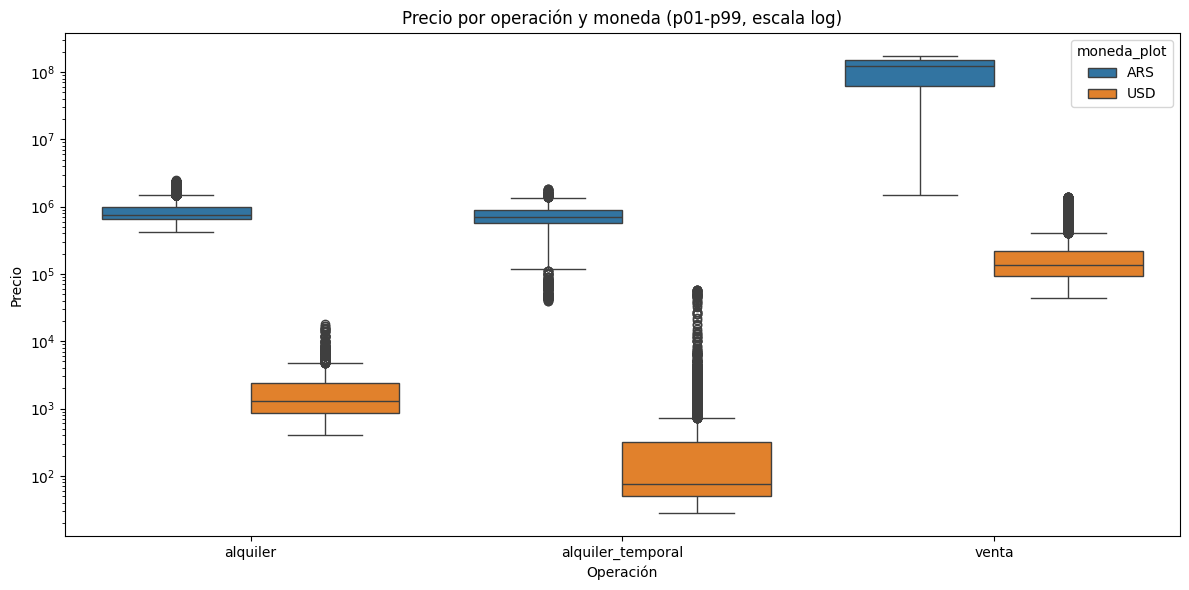

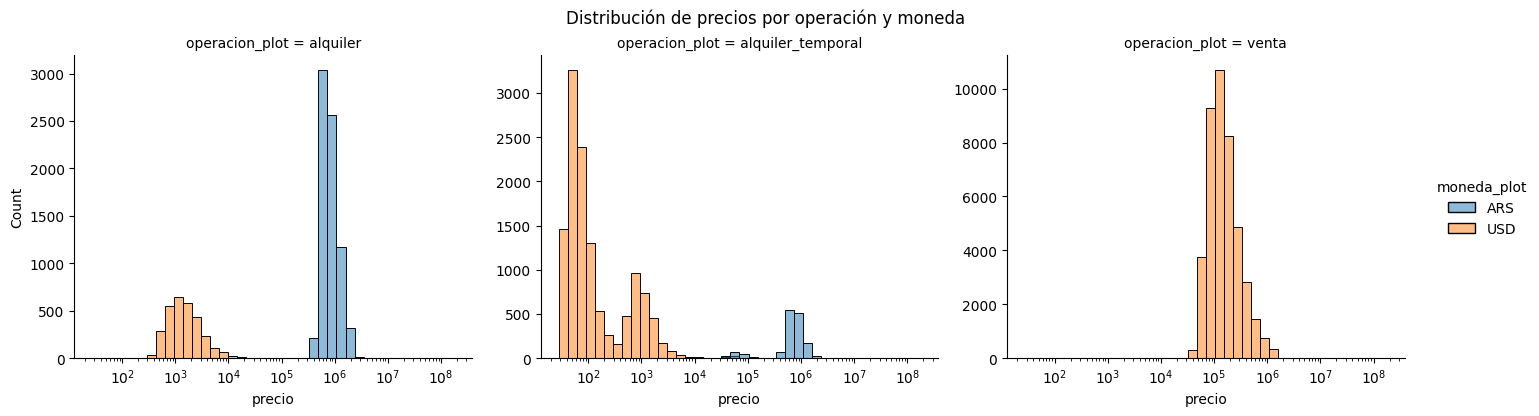

In [12]:
def recortar_por_grupo(df, value_col, group_cols, p_low=0.01, p_high=0.99):
    partes = []
    base = df[df[value_col].notna() & (df[value_col] > 0)].copy()
    for _, grupo in base.groupby(group_cols, dropna=False):
        if len(grupo) < 20:
            partes.append(grupo)
            continue
        low = grupo[value_col].quantile(p_low)
        high = grupo[value_col].quantile(p_high)
        partes.append(grupo[grupo[value_col].between(low, high)])
    return pd.concat(partes, ignore_index=True) if partes else pd.DataFrame()

precio_df = recortar_por_grupo(df_eda, 'precio', ['operacion_plot', 'moneda_plot']) if 'precio' in df_eda.columns else pd.DataFrame()

if not precio_df.empty:
    resumen_precios = (
        precio_df.groupby(['operacion_plot', 'moneda_plot'])['precio']
        .agg(n='count', mediana='median', media='mean', p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
        .round(2)
        .reset_index()
        .sort_values(['operacion_plot', 'moneda_plot'])
    )
    display(resumen_precios)
    resumen_precios.to_csv(REPORTS_DIR / 'eda_inicial_resumen_precios_v1.csv', index=False)

    if HAS_SEABORN:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=precio_df, x='operacion_plot', y='precio', hue='moneda_plot')
        plt.yscale('log')
        plt.title('Precio por operación y moneda (p01-p99, escala log)')
        plt.xlabel('Operación')
        plt.ylabel('Precio')
        plt.tight_layout()
        plt.show()

        g = sns.displot(
            data=precio_df,
            x='precio',
            col='operacion_plot',
            hue='moneda_plot',
            kind='hist',
            bins=40,
            log_scale=True,
            facet_kws={'sharex': False, 'sharey': False},
            height=4,
            aspect=1.2,
        )
        g.fig.suptitle('Distribución de precios por operación y moneda', y=1.03)
        plt.show()
else:
    print('No hay datos suficientes de precio positivo para graficar.')

**Interpretación pendiente.**

- Diferencias visibles entre venta, alquiler tradicional y temporario:
- Monedas predominantes por operación:
- Comparaciones que todavía no conviene cerrar hasta normalizar a USD/precio mensual:
- Outliers

## 7. Precio por m², superficie y ambientes

Estas variables son más comparables que el precio absoluto, pero dependen de cobertura y de reglas de imputación/reconstrucción previas. Se revisan por operación, fuente y moneda.

precio_m2_ref                         superficie_ref_m2                ambientes_ref              dormitorios_ref               \
                                                    count      median        mean             count median    mean         count median  mean           count median  mean   
fuente_plot   operacion_plot    moneda_plot                                                                                                                                  
airbnb        alquiler_temporal USD                     0         NaN         NaN                 0    NaN     NaN          9594    2.0  2.05            9594    1.0  1.05   
argenprop     alquiler          ARS                    58    19687.50    20895.48                58   40.5   48.90            53    2.0  2.45              52    1.0  1.46   
                                USD                    13       20.00       21.24                13  100.0  105.85            14    3.0  3.36              14    2.0  2.21   
              venta             USD                    78     2852.40     2972.60                78   57.5   72.59            75    3.0  2.84              67    2.0  1.99   
mercado_libre alquiler          ARS                  7201    19444.44    21376.29              7201   40.0   46.48          7002    2.0  2.01              26    1.0  1.27   
                                USD                  2634       21.05       80.60              2634   62.0   87.36          2601    2.0  2.60              12    1.0  1.17   
              alquiler_temporal ARS                  1484    18169.86    18497.25              1484   40.0   43.93          1419    2.0  1.96               1    1.0  1.00   
                                USD                  2991       21.43      144.54              2991   45.0   54.61          2910    2.0  2.06               6    2.0  1.67   
              venta             ARS                     3  4069488.37  2904135.78                 3   43.0   44.67             3    2.0  2.00               0    NaN   NaN   
                                USD                 42733     2691.67     3024.42             42733   52.0   81.48         42314    2.0  2.54             155    2.0  2.59   
zonaprop      alquiler          ARS                   153    19047.62    19002.05               153   42.0   51.56           151    2.0  1.88              97    1.0  1.45   
                                USD                   338       18.71       20.28               338   67.0   95.49           342    2.0  2.58             290    2.0  1.78   
              venta             USD                   476     2614.87     2944.64               476   76.0  113.36           476    3.0  2.98             375    2.0  2.18   
                                sin_moneda              0         NaN         NaN                 8  181.0  219.00             8    4.0  3.38               4    3.0  2.50   

                                            banios_ref               
                                                 count median  mean  
fuente_plot   operacion_plot    moneda_plot                          
airbnb        alquiler_temporal USD               9590    1.0  1.12  
argenprop     alquiler          ARS                 33    1.0  3.79  
                                USD                  5    2.0  2.40  
              venta             USD                 34    1.0  4.03  
mercado_libre alquiler          ARS               7104    1.0  1.13  
                                USD               2585    1.0  1.65  
              alquiler_temporal ARS               1463    1.0  1.13  
                                USD               2940    1.0  1.22  
              venta             ARS                  3    1.0  1.33  
                                USD              41835    1.0  1.40  
zonaprop      alquiler          ARS                152    1.0  1.12  
                                USD                337    1.0  1.59  
              venta             USD

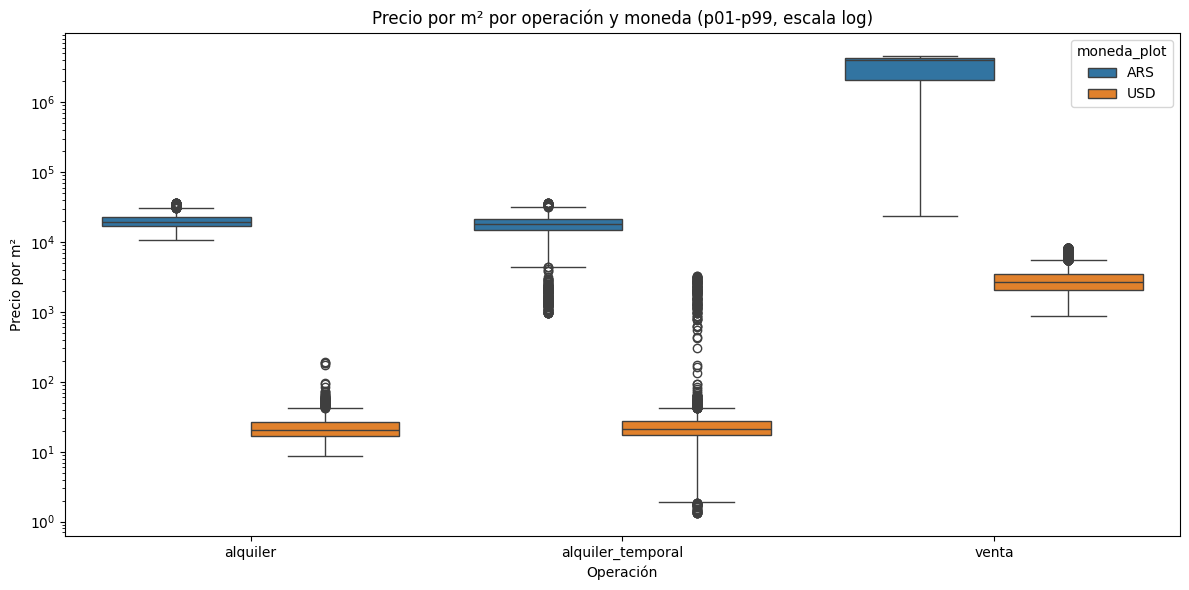

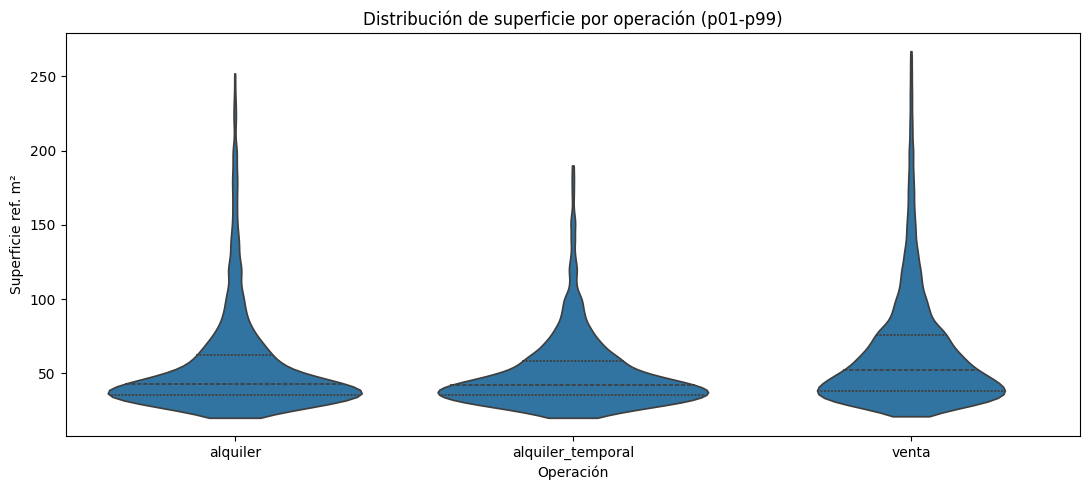

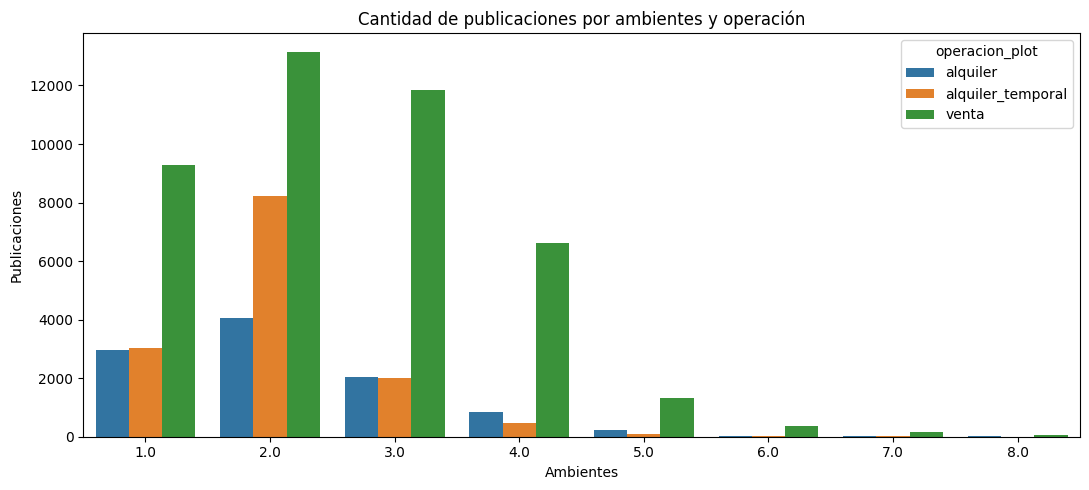

In [13]:
metric_cols = [col for col in ['precio_m2_ref', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref', 'expensas'] if col in df_eda.columns]

if metric_cols:
    metricas_operacion = (
        df_eda.groupby(['fuente_plot', 'operacion_plot', 'moneda_plot'])[metric_cols]
        .agg(['count', 'median', 'mean'])
        .round(2)
    )
    display(metricas_operacion)
    metricas_operacion.to_csv(REPORTS_DIR / 'eda_inicial_metricas_por_fuente_operacion_v1.csv')

if 'precio_m2_ref' in df_eda.columns:
    pm2_df = recortar_por_grupo(df_eda, 'precio_m2_ref', ['operacion_plot', 'moneda_plot'])
    if not pm2_df.empty and HAS_SEABORN:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=pm2_df, x='operacion_plot', y='precio_m2_ref', hue='moneda_plot')
        plt.yscale('log')
        plt.title('Precio por m² por operación y moneda (p01-p99, escala log)')
        plt.xlabel('Operación')
        plt.ylabel('Precio por m²')
        plt.tight_layout()
        plt.show()

if 'superficie_ref_m2' in df_eda.columns:
    sup_df = recortar_por_grupo(df_eda, 'superficie_ref_m2', ['operacion_plot'], p_low=0.01, p_high=0.99)
    if not sup_df.empty and HAS_SEABORN:
        plt.figure(figsize=(11, 5))
        sns.violinplot(data=sup_df, x='operacion_plot', y='superficie_ref_m2', inner='quartile', cut=0)
        plt.title('Distribución de superficie por operación (p01-p99)')
        plt.xlabel('Operación')
        plt.ylabel('Superficie ref. m²')
        plt.tight_layout()
        plt.show()

if 'ambientes_ref' in df_eda.columns and HAS_SEABORN:
    amb_df = df_eda[df_eda['ambientes_ref'].notna()].copy()
    amb_df = amb_df[amb_df['ambientes_ref'].between(1, 8)]
    if not amb_df.empty:
        plt.figure(figsize=(11, 5))
        sns.countplot(data=amb_df, x='ambientes_ref', hue='operacion_plot')
        plt.title('Cantidad de publicaciones por ambientes y operación')
        plt.xlabel('Ambientes')
        plt.ylabel('Publicaciones')
        plt.tight_layout()
        plt.show()

**Interpretación pendiente.**

- Segmentos con mejor lectura de precio/m²:
- Operaciones donde superficie o ambientes tienen menor confiabilidad:
- Primeras señales de diferencias por tamaño de unidad:

## 8. Relación precio-superficie

Este gráfico no intenta modelar todavía; busca verificar si las relaciones básicas tienen sentido y si conviene usar transformaciones logarítmicas en análisis posteriores.

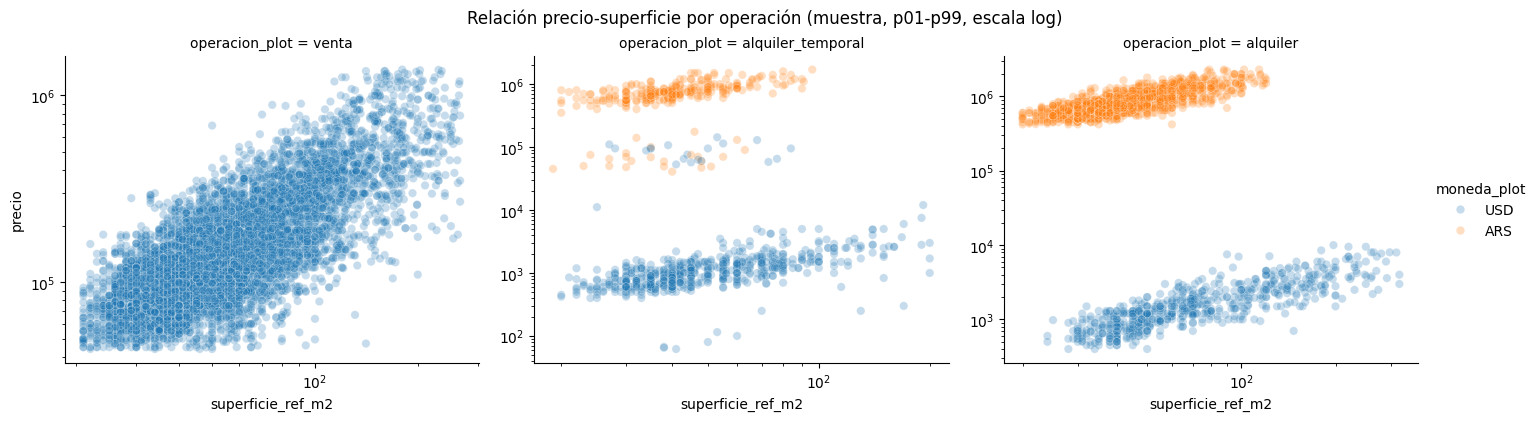

/tmp/ipykernel_3525/1568649312.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,operacion_plot,moneda_plot,n,spearman_precio_superficie,spearman_pm2_superficie
0,alquiler,ARS,7169.0,0.736,-0.366
1,alquiler,USD,2891.0,0.845,-0.019
2,alquiler_temporal,ARS,1430.0,0.526,-0.349
3,alquiler_temporal,USD,2885.0,0.599,-0.202
4,venta,USD,41966.0,0.745,0.030


In [14]:
cols_relacion = {'precio', 'superficie_ref_m2', 'precio_m2_ref'}
if cols_relacion.issubset(df_eda.columns):
    rel_df = df_eda[
        df_eda['precio'].notna()
        & df_eda['superficie_ref_m2'].notna()
        & (df_eda['precio'] > 0)
        & (df_eda['superficie_ref_m2'] > 0)
    ].copy()

    partes = []
    for _, grupo in rel_df.groupby(['operacion_plot', 'moneda_plot'], dropna=False):
        if len(grupo) < 30:
            continue
        p_precio = grupo['precio'].quantile([0.01, 0.99])
        p_sup = grupo['superficie_ref_m2'].quantile([0.01, 0.99])
        partes.append(grupo[
            grupo['precio'].between(p_precio.loc[0.01], p_precio.loc[0.99])
            & grupo['superficie_ref_m2'].between(p_sup.loc[0.01], p_sup.loc[0.99])
        ])
    rel_df = pd.concat(partes, ignore_index=True) if partes else pd.DataFrame()

    if not rel_df.empty:
        sample_df = rel_df.sample(min(len(rel_df), 12000), random_state=42)
        if HAS_SEABORN:
            g = sns.relplot(
                data=sample_df,
                x='superficie_ref_m2',
                y='precio',
                col='operacion_plot',
                hue='moneda_plot',
                kind='scatter',
                alpha=0.25,
                height=4,
                aspect=1.2,
                facet_kws={'sharex': False, 'sharey': False},
            )
            for ax in g.axes.flat:
                ax.set_xscale('log')
                ax.set_yscale('log')
            g.fig.suptitle('Relación precio-superficie por operación (muestra, p01-p99, escala log)', y=1.03)
            plt.show()

        correlaciones_basicas = (
            rel_df.groupby(['operacion_plot', 'moneda_plot'])
            .apply(lambda g: pd.Series({
                'n': len(g),
                'spearman_precio_superficie': g[['precio', 'superficie_ref_m2']].corr(method='spearman').iloc[0, 1],
                'spearman_pm2_superficie': g[['precio_m2_ref', 'superficie_ref_m2']].dropna().corr(method='spearman').iloc[0, 1]
                    if g[['precio_m2_ref', 'superficie_ref_m2']].dropna().shape[0] >= 3 else np.nan,
            }))
            .reset_index()
            .round(3)
        )
        display(correlaciones_basicas)
        correlaciones_basicas.to_csv(REPORTS_DIR / 'eda_inicial_correlaciones_precio_superficie_v1.csv', index=False)
else:
    print('No están todas las columnas necesarias para precio-superficie.')

**Interpretación pendiente.**

- Relación esperada entre precio y superficie:
- Segmentos donde aparecen patrones raros:
- Transformaciones recomendadas para EDA posterior:

## 9. Atributos internos y amenities

Se revisan atributos disponibles dentro de las publicaciones. Son señales propias de la base, todavía sin sumar entorno urbano externo.

In [15]:
amenity_candidates = [
    'balcon', 'balcon_o_patio', 'terraza', 'patio', 'pileta', 'parrilla', 'jardin', 'cochera',
    'cocheras', 'cochera_mencionada', 'amenities_mencionadas', 'apto_credito', 'apto_profesional',
    'permite_mascotas', 'amoblado'
]
amenity_cols = [col for col in amenity_candidates if col in df_eda.columns]

if amenity_cols:
    amenity_numeric = []
    for col in amenity_cols:
        serie = df_eda[col]
        if pd.api.types.is_numeric_dtype(serie) or pd.api.types.is_bool_dtype(serie):
            amenity_numeric.append(col)

    if amenity_numeric:
        resumen_amenities = (
            df_eda.groupby(['fuente_plot', 'operacion_plot'])[amenity_numeric]
            .mean(numeric_only=True)
            .mul(100)
            .round(1)
            .reset_index()
        )
        display(resumen_amenities)
        resumen_amenities.to_csv(REPORTS_DIR / 'eda_inicial_amenities_por_segmento_v1.csv', index=False)

        if HAS_SEABORN:
            heat = resumen_amenities.copy()
            heat['segmento'] = heat['fuente_plot'] + ' | ' + heat['operacion_plot']
            heat = heat.set_index('segmento')[amenity_numeric]
            plt.figure(figsize=(12, max(4, 0.45 * len(heat))))
            sns.heatmap(heat, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '% / valor medio'})
            plt.title('Atributos y amenities internos por fuente-operación')
            plt.xlabel('Atributo')
            plt.ylabel('Segmento')
            plt.tight_layout()
            plt.show()
    else:
        print('Hay columnas candidatas de amenities, pero ninguna es numérica/booleana para promediar directamente:', amenity_cols)
else:
    print('No se encontraron columnas de amenities comparables en esta base.')

No se encontraron columnas de amenities comparables en esta base.


**Interpretación pendiente.**

- Atributos con señal comparable entre fuentes:
- Atributos que dependen demasiado del scraping/texto:
- Variables que conviene mantener para hipótesis posteriores:

## 10. Marcas de outliers y calidad post-tratamiento

El notebook 04 define el tratamiento de outliers. Acá solo se mira si las marcas remanentes se concentran en algún segmento y si pueden afectar las visualizaciones iniciales.

In [16]:
outlier_cols = [col for col in df_eda.columns if 'outlier' in col.lower()]

if outlier_cols:
    outlier_resumen = (
        df_eda.groupby(['fuente_plot', 'operacion_plot'])[outlier_cols]
        .mean(numeric_only=True)
        .mul(100)
        .round(2)
        .reset_index()
    )
    display(outlier_resumen)
    outlier_resumen.to_csv(REPORTS_DIR / 'eda_inicial_outliers_por_segmento_v1.csv', index=False)
else:
    print('No se encontraron columnas con marcas de outliers en la base cargada.')

,fuente_plot,operacion_plot,precio_outlier_p01_p99_flag,precio_m2_ref_outlier_p01_p99_flag,superficie_ref_m2_outlier_p01_p99_flag,ambientes_ref_outlier_p01_p99_flag,dormitorios_ref_outlier_p01_p99_flag,banios_ref_outlier_p01_p99_flag,altura_outlier_p01_p99_flag,precio_outlier_iqr_flag,precio_m2_ref_outlier_iqr_flag,superficie_ref_m2_outlier_iqr_flag,ambientes_ref_outlier_iqr_flag,dormitorios_ref_outlier_iqr_flag,banios_ref_outlier_iqr_flag,altura_outlier_iqr_flag,precio_noche_estimado_outlier_p01_p99_flag,precio_mensual_estimado_outlier_p01_p99_flag,latitud_outlier_p01_p99_flag,longitud_outlier_p01_p99_flag,rating_outlier_p01_p99_flag,reviews_outlier_p01_p99_flag,precio_noche_estimado_outlier_iqr_flag,precio_mensual_estimado_outlier_iqr_flag
0,airbnb,alquiler_temporal,1.98,NaN,NaN,0.99,0.45,0.65,NaN,8.83,NaN,NaN,32.56,15.62,9.13,NaN,1.98,1.98,1.99,1.98,0.75,0.83,8.83,8.83
1,argenprop,alquiler,5.00,5.00,3.75,2.50,1.25,1.25,5.00,7.50,1.25,10.00,1.25,0.00,5.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,argenprop,venta,2.44,2.44,2.44,0.00,0.00,1.22,1.22,8.54,2.44,6.10,0.00,0.00,1.22,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,mercado_libre,alquiler,1.75,2.00,1.82,0.80,0.00,0.19,1.63,7.92,3.26,7.15,2.09,0.02,8.76,1.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mercado_libre,alquiler_temporal,1.98,2.00,1.69,0.69,0.00,0.36,1.45,11.42,10.95,6.32,1.58,0.00,13.42,1.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,mercado_libre,venta,1.97,2.01,1.69,0.71,0.00,0.40,1.60,9.16,4.95,6.77,4.52,0.01,1.69,1.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,zonaprop,alquiler,2.22,2.42,2.02,0.81,0.40,0.81,NaN,7.88,4.85,9.29,6.87,2.42,5.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,zonaprop,venta,1.86,2.06,1.86,0.82,0.21,0.82,NaN,11.55,7.22,3.92,0.82,0.41,5.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretación pendiente.**

- Segmentos con mayor presencia de outliers:
- Variables donde los extremos son esperables por el mercado:
- Variables donde conviene mantener flags para análisis posterior:

## 11. Precio por m2 según barrio

Se usa la mediana ya que el precio cuenta con outliers. Utilizamos barrios con mínimo 1000 publicaciones. Cuando implementemos las variables externas, se verá de forma más clara el por qué de estos precios.

In [17]:
# Filtrar datos válidos

pm2_barrio = df_eda[
    df_eda['precio_m2_ref'].notna() &
    (df_eda['precio_m2_ref'] > 0) &
    df_eda['barrio_norm'].notna()
].copy()

# Nos quedamos con barrios con al menos 30 publicaciones
barrios_validos = (
    pm2_barrio['barrio_norm']
    .value_counts()
)

barrios_validos = barrios_validos[
    barrios_validos >= 1000
].index

pm2_barrio = pm2_barrio[
    pm2_barrio['barrio_norm'].isin(barrios_validos)
]

In [18]:
precio_m2_barrio = (
    pm2_barrio
    .groupby('barrio_norm')
    .agg(
        mediana_precio_m2=('precio_m2_ref', 'median'),
        publicaciones=('precio_m2_ref', 'count')
    )
    .sort_values('mediana_precio_m2', ascending=False)
)

display(precio_m2_barrio)

,mediana_precio_m2,publicaciones
barrio_norm,,
puerto madero,5045.250,2402
nunez,3903.725,2640
belgrano,3707.255,3236
colegiales,3394.590,1629
saavedra,3307.740,1445
villa urquiza,3260.870,2607
caballito,3216.220,2953
villa devoto,3181.820,1809
palermo,3095.120,4941


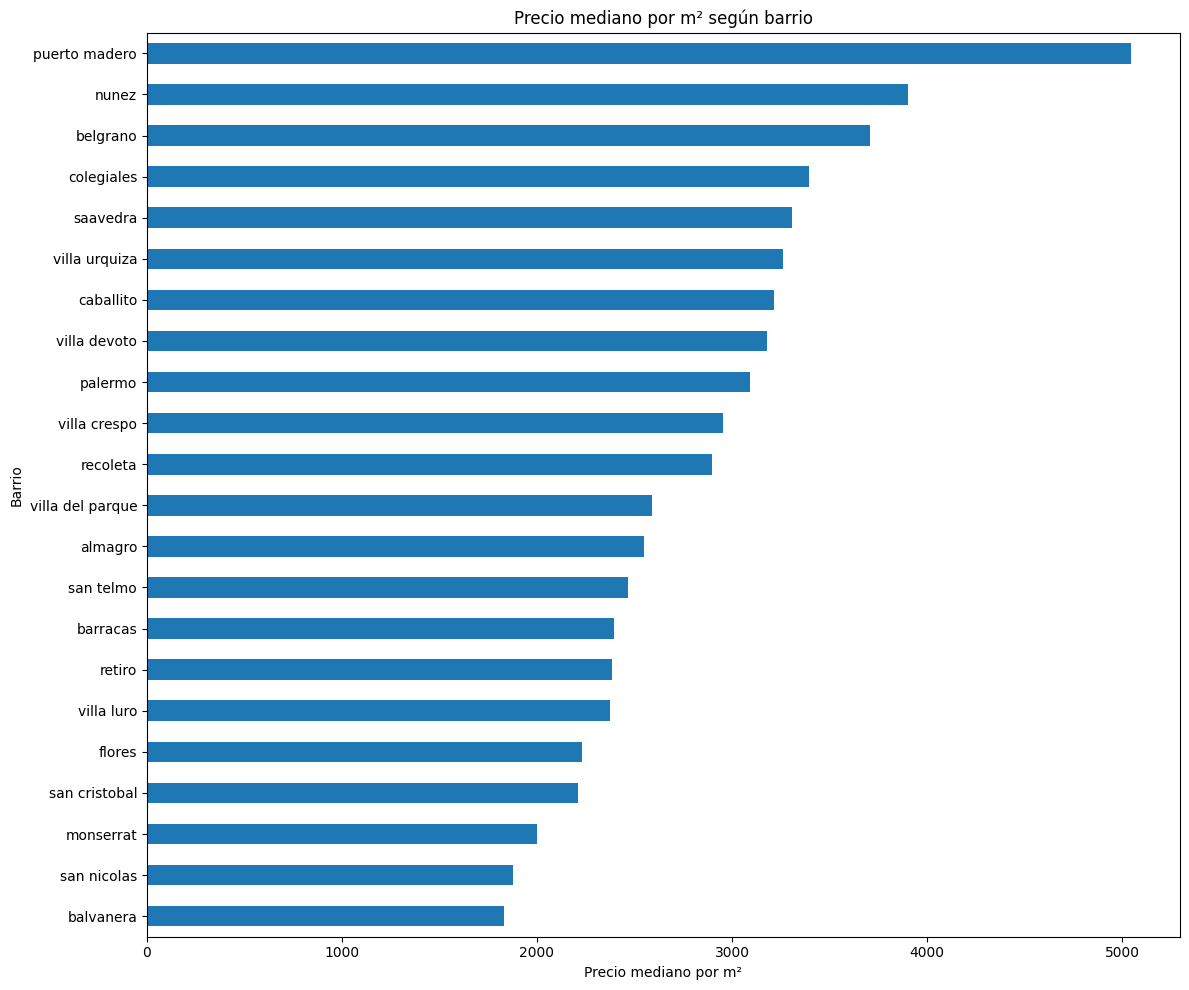

In [19]:
plt.figure(figsize=(12, 10))

precio_m2_barrio['mediana_precio_m2'].sort_values().plot(
    kind='barh'
)

plt.title('Precio mediano por m² según barrio')
plt.xlabel('Precio mediano por m²')
plt.ylabel('Barrio')
plt.tight_layout()
plt.show()

Brecha de mercado superior a 2,5 veces: Puerto Madero lidera con medianas sobre los 5.000 USD/m², mientras que Balvanera, San Nicolás y Monserrat se ubican en el extremo inferior, por debajo de los 2.000 USD/m².   Predominio del Corredor Norte: Barrios como Núñez, Belgrano, Colegiales, Saavedra y Villa Urquiza concentran los valores más altos de la muestra (entre 3.300 y 3.900 USD/m²).   Franja media y turística: Palermo (3.100 USD/m²) y Recoleta (2.900 USD/m²) se sitúan en un rango medio-alto, donde la mezcla de modalidades (venta vs. alquiler temporario/tradicional) puede influir en la mediana general.   Macrocentro y Sur: Almagro, San Telmo, Barracas, Retiro y Flores muestran mayor homogeneidad en un rango intermedio-bajo (2.200 a 2.600 USD/m²).  

## 12. ¿El barrio está asociado a una determinada tipología?

Nuevamente utilizamos barrios con mínimo 1000 publicaciones. Nos sirve para ver si los barrios tienen distinta composición de ambientes. Por ejemplo, podemos ver si los más caros suelen tener más ambientes.

In [20]:
tipologia_df = df_eda[
    df_eda['ambientes_ref'].notna() &
    df_eda['barrio_norm'].notna()
].copy()

tipologia_df = tipologia_df[
    tipologia_df['ambientes_ref'].between(1, 8)
]

tipologia_df['tipologia'] = np.select(
    [
        tipologia_df['ambientes_ref'] == 1,
        tipologia_df['ambientes_ref'] == 2,
        tipologia_df['ambientes_ref'] == 3,
        tipologia_df['ambientes_ref'] >= 4
    ],
    [
        '1 ambiente',
        '2 ambientes',
        '3 ambientes',
        '4 o más'
    ],
    default='Sin dato'
)

In [21]:
barrios_validos = (
    tipologia_df['barrio_norm']
    .value_counts()
)

barrios_validos = barrios_validos[
    barrios_validos >= 1000
].index

tipologia_df = tipologia_df[
    tipologia_df['barrio_norm'].isin(barrios_validos)
]

In [22]:
composicion_tipologia = pd.crosstab(
    tipologia_df['barrio_norm'],
    tipologia_df['tipologia'],
    normalize='index'
) * 100

display(composicion_tipologia.round(1))

tipologia,1 ambiente,2 ambientes,3 ambientes,4 o más
barrio_norm,,,,
almagro,25.7,37.4,24.0,12.9
balvanera,21.2,34.2,25.9,18.6
barracas,16.8,37.7,29.5,16.0
belgrano,20.7,36.3,21.5,21.5
caballito,17.6,34.1,27.3,21.0
colegiales,18.7,36.8,25.6,18.9
flores,16.2,30.1,27.5,26.2
monserrat,34.4,37.2,18.9,9.5
nunez,22.6,40.1,22.9,14.3


<Figure size 1400x1000 with 0 Axes>

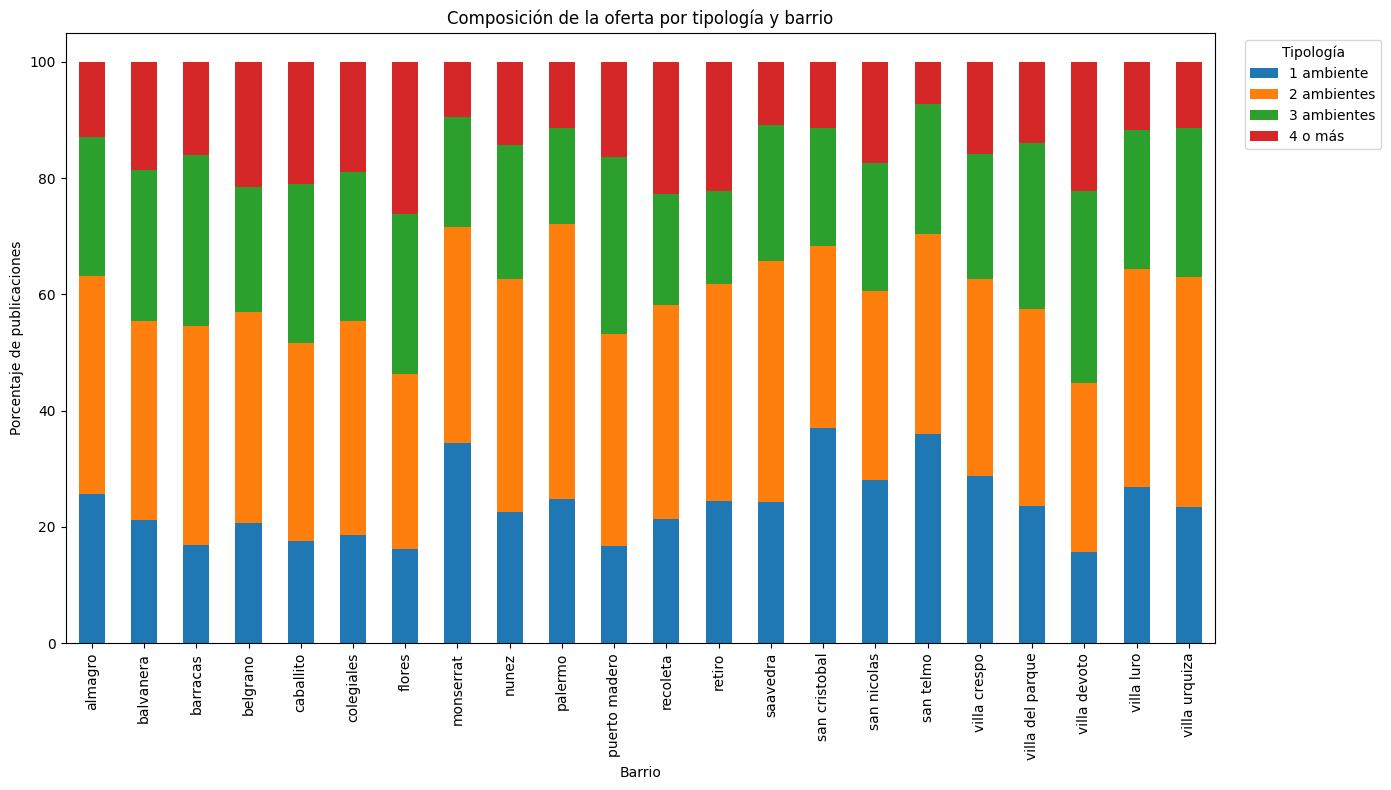

In [23]:
plt.figure(figsize=(14, 10))

composicion_tipologia.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8)
)

plt.title('Composición de la oferta por tipología y barrio')
plt.xlabel('Barrio')
plt.ylabel('Porcentaje de publicaciones')
plt.legend(title='Tipología', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

La composición de la oferta no es homogénea entre barrios: algunos presentan una mayor concentración de unidades pequeñas. Esto plantea la necesidad de analizar posteriormente si estas diferencias se relacionan con la estructura de los hogares de cada barrio.

## 13. Lectura preliminar por hipótesis antes de fuentes externas

Esta tabla ordena qué puede mirarse ya con la base interna y qué queda pendiente para los notebooks 06 y 07. No reemplaza la validación estadística posterior.

In [24]:
lectura_preliminar = pd.DataFrame([
    {
        'hipotesis/eje': 'H1 - atractivo turístico y temporarios',
        'senal_interna_disponible': 'Volumen Airbnb/temporario por barrio disponible y precios estimados si existen.',
        'limitacion_actual': 'Todavía no hay gastronomía, cultura, espacios verdes ni barrio oficial.',
        'pasa_a': 'Notebook 06/07',
    },
    {
        'hipotesis/eje': 'H2 - servicios y perfil residencial',
        'senal_interna_disponible': 'Ambientes, superficie, expensas y atributos internos por operación.',
        'limitacion_actual': 'Faltan escuelas, hospitales, hogares y estructura habitacional del Censo.',
        'pasa_a': 'Notebook 06/07',
    },
    {
        'hipotesis/eje': 'H3 - transporte y precio',
        'senal_interna_disponible': 'Precio/m² y barrio/comuna preliminar.',
        'limitacion_actual': 'No hay distancia a subte/tren/MetroBus ni coordenadas completas.',
        'pasa_a': 'Notebook 06/07',
    },
    {
        'hipotesis/eje': 'H4 - presión de oferta y vivienda',
        'senal_interna_disponible': 'Cantidad de publicaciones por operación y territorio preliminar.',
        'limitacion_actual': 'Faltan denominadores por población, hogares, viviendas y viviendas desocupadas.',
        'pasa_a': 'Notebook 06/07',
    },
])

display(lectura_preliminar)
lectura_preliminar.to_csv(REPORTS_DIR / 'eda_inicial_lectura_preliminar_hipotesis_v1.csv', index=False)

,hipotesis/eje,senal_interna_disponible,limitacion_actual,pasa_a
0,H1 - atractivo turístico y temporarios,Volumen Airbnb/temporario por barrio disponibl...,"Todavía no hay gastronomía, cultura, espacios ...",Notebook 06/07
1,H2 - servicios y perfil residencial,"Ambientes, superficie, expensas y atributos in...","Faltan escuelas, hospitales, hogares y estruct...",Notebook 06/07
2,H3 - transporte y precio,Precio/m² y barrio/comuna preliminar.,No hay distancia a subte/tren/MetroBus ni coor...,Notebook 06/07
3,H4 - presión de oferta y vivienda,Cantidad de publicaciones por operación y terr...,"Faltan denominadores por población, hogares, v...",Notebook 06/07


**Interpretación pendiente.**

- Señales internas más útiles para seguir:
- Hipótesis que todavía no pueden evaluarse con la base actual:
- Variables que deberían entrar al dataset enriquecido del notebook 06:

## 14. Cierre del EDA inicial

**Composición de la base**

Dominancia de Mercado Libre: La plataforma Mercado Libre representa la gran mayoría del volumen total de datos, concentrando 57.149 de las 67.887 publicaciones analizadas.

Sesgo por tipo de operación: Las operaciones de venta componen el segmento principal de la base (43.345 registros), seguidas por los alquileres temporales (14.090) y los alquileres tradicionales (10.452).

Especialización de fuentes secundarias:

Airbnb: Aporta exclusivamente oferta de alquiler temporal (9.596 registros).

Zonaprop y Argenprop: Muestran una presencia minoritaria en este corte pre-enriquecimiento (980 y 162 registros, respectivamente), divididos entre venta y alquiler tradicional.


**Cobertura remanente de variables**

Variables listas para análisis:

Precio y Moneda: Presentan una cobertura prácticamente perfecta ($99,99\%$), sirviendo como pilar para los análisis cuantitativos iniciales.

Ambientes y Baños: Exhiben niveles de nulos mínimos ($1,36\%$ y $2,02\%$, respectivamente), estando en condiciones óptimas para su uso directo.

Superficie y Precio por m²: Cuentan con una cobertura utilizable cercana al $85,7\%$ global.

Variables con faltantes estructurales o dependientes de reconstrucción:

Dormitorios: Presenta un $84,25\%$ de nulos a nivel general. Esto se debe a una omisión estructural en las publicaciones preprocesadas de Mercado Libre (donde la métrica principal capturada es el número de ambientes). Requiere reglas de imputación o estimación en etapas posteriores si se desea utilizar como feature explicativa.

Superficie en Airbnb: Registra un $100\%$ de nulos en la fuente Airbnb por diseño de la plataforma original.

Coordenadas geográficas (latitud / longitud): Muestran una ausencia del $85,86\%$ en la consolidada propia, limitándose por el momento a los datos provenientes de Airbnb. La dimensión espacial precisa dependerá íntegramente del proceso de geocodificación a desarrollar en las siguientes etapas.

**Necesidad de la normalización oficial de barrios (Territorio)**

Inconsistencia y dispersión de etiquetas: La variable barrio_norm registra $223$ categorías distintas, cifra que supera ampliamente los $48$ barrios oficiales de la Ciudad Autónoma de Buenos Aires.

Ruido toponímico: Se detectan $139$ etiquetas con $3$ o menos publicaciones. Muchas de estas entradas corresponden a nombres de calles o avenidas (ej. Avenida Corrientes, Blanco Encalada, Fray Justo Santa María de Oro), sub-barrios no oficiales (ej. Abasto) o localidades fuera de la jurisdicción de CABA (ej. La Plata, Mar de Ajó).

Justificación de enriquecimiento: No es posible emitir conclusiones territoriales ni comparaciones de precios agregadas por barrio válidas sin antes vincular las publicaciones con el mapa vectorial oficial de la Ciudad (GeoJSON de barrios/comunas) y estandarizar la variable geográfica en el notebook 06.


**Patrones iniciales de precios**

Heterogeneidad de monedas: Coexisten publicaciones nominadas en dólares ($USD$) y pesos ($ARS$). Las comparaciones directas de precios absolutos entre la venta (predominantemente dolarizada) y los alquileres no son válidas en esta instancia.

Distribución asimétrica: Los valores absolutos de precio y precio por $\text{m}^2$ muestran distribuciones fuertemente sesgadas a la derecha, con presencia de valores extremos (outliers).

Límite analítico: Se diferencian preliminarmente los rangos de precios por tipo de operación, pero se postergan las comparaciones definitivas y el cálculo de indicadores reales de mercado hasta aplicar la conversión a moneda común (tipo de cambio oficial/paralelo) y la georreferenciación oficial en los siguientes notebooks.


**Próximo paso:** pasar al notebook 06 para incorporar Censo, BA Data, geocodificación, tipo de cambio y variables por publicación/barrio/comuna.